In [15]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
g = 9.81
m = 1.0       # mass (kg) — keep it simple
dt = 0.01
t_max = 4.0

# Initial conditions: launched upward
x, y = 0.0, 0.0
vx, vy = 15.0, 20.0

# Storage
data = {'t': [0], 'x': [x], 'y': [y], 'vx': [vx], 'vy': [vy],
        'KE': [0.5*m*(vx**2+vy**2)], 'PE': [m*g*y], 'E': [0.5*m*(vx**2+vy**2)+m*g*y]}

t = 0.0
while t < t_max and y >= 0:
    # Acceleration (gravity only — conservative)
    ax, ay = 0.0, -g

    # ── STANDARD EULER ──
    vx_old, vy_old = vx, vy   # save old velocity
    vx = vx + ax * dt
    vy = vy + ay * dt
    x  = x + vx_old * dt      # use OLD velocity for position
    y  = y + vy_old * dt

    t += dt

    # Energy tracking
    KE = 0.5 * m * (vx**2 + vy**2)
    PE = m * g * y
    E  = KE + PE

    data['t'].append(t)
    data['x'].append(x); data['y'].append(y)
    data['vx'].append(vx); data['vy'].append(vy)
    data['KE'].append(KE); data['PE'].append(PE); data['E'].append(E)

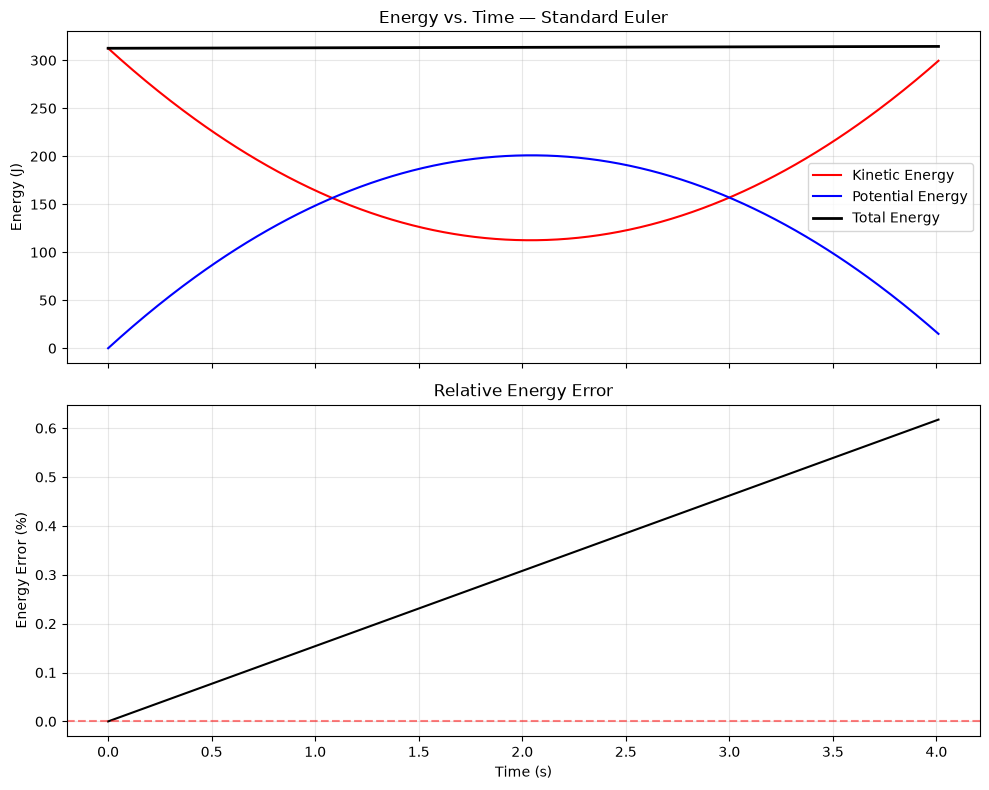

In [16]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

# Top panel: KE, PE, Total
ax1.plot(data['t'], data['KE'], 'r-', label='Kinetic Energy')
ax1.plot(data['t'], data['PE'], 'b-', label='Potential Energy')
ax1.plot(data['t'], data['E'],  'k-', label='Total Energy', linewidth=2)
ax1.set_ylabel('Energy (J)')
ax1.legend()
ax1.set_title('Energy vs. Time — Standard Euler')
ax1.grid(True, alpha=0.3)

# Bottom panel: energy error
E0 = data['E'][0]
E_err = [(e - E0) / abs(E0) * 100 for e in data['E']]
ax2.plot(data['t'], E_err, 'k-')
ax2.set_xlabel('Time (s)')
ax2.set_ylabel('Energy Error (%)')
ax2.set_title('Relative Energy Error')
ax2.grid(True, alpha=0.3)
ax2.axhline(y=0, color='r', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [17]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
g = 9.81
m = 1.0       # mass (kg) — keep it simple
dt = .1
t_max = 4.0

# Initial conditions: launched upward
x, y = 0.0, 0.0
vx, vy = 15.0, 20.0

# Storage
data = {'t': [0], 'x': [x], 'y': [y], 'vx': [vx], 'vy': [vy],
        'KE': [0.5*m*(vx**2+vy**2)], 'PE': [m*g*y], 'E': [0.5*m*(vx**2+vy**2)+m*g*y]}

t = 0.0
while t < t_max and y >= 0:
    # Acceleration (gravity only — conservative)
    ax, ay = 0.0, -g

    # ── STANDARD EULER ──
    vx_old, vy_old = vx, vy   # save old velocity
    vx = vx + ax * dt
    vy = vy + ay * dt
    x  = x + vx_old * dt      # use OLD velocity for position
    y  = y + vy_old * dt

    t += dt

    # Energy tracking
    KE = 0.5 * m * (vx**2 + vy**2)
    PE = m * g * y
    E  = KE + PE

    data['t'].append(t)
    data['x'].append(x); data['y'].append(y)
    data['vx'].append(vx); data['vy'].append(vy)
    data['KE'].append(KE); data['PE'].append(PE); data['E'].append(E)

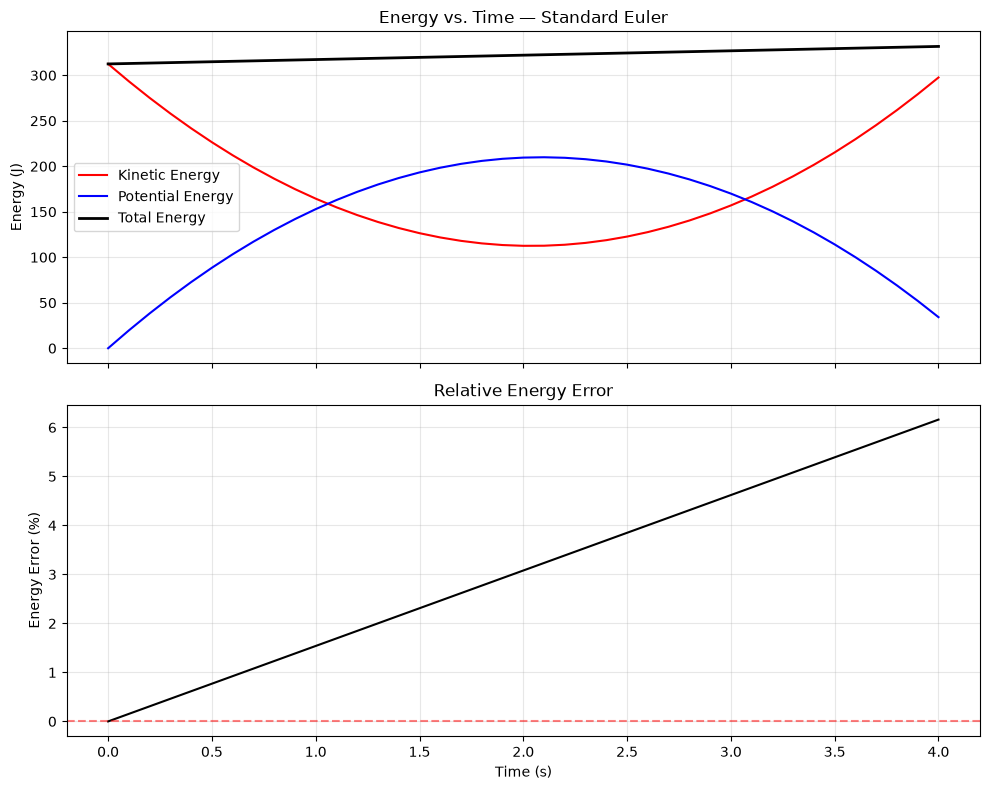

In [18]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

# Top panel: KE, PE, Total
ax1.plot(data['t'], data['KE'], 'r-', label='Kinetic Energy')
ax1.plot(data['t'], data['PE'], 'b-', label='Potential Energy')
ax1.plot(data['t'], data['E'],  'k-', label='Total Energy', linewidth=2)
ax1.set_ylabel('Energy (J)')
ax1.legend()
ax1.set_title('Energy vs. Time — Standard Euler')
ax1.grid(True, alpha=0.3)

# Bottom panel: energy error
E0 = data['E'][0]
E_err = [(e - E0) / abs(E0) * 100 for e in data['E']]
ax2.plot(data['t'], E_err, 'k-')
ax2.set_xlabel('Time (s)')
ax2.set_ylabel('Energy Error (%)')
ax2.set_title('Relative Energy Error')
ax2.grid(True, alpha=0.3)
ax2.axhline(y=0, color='r', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

Try it: Run this with dt = 0.01, then with dt = 0.1. Watch the energy error panel. Does the total energy stay constant? Does it drift up, down, or oscillate? Record what you see — you'll need this observation in a moment.

The total energy does not stay constant. It drifts up.

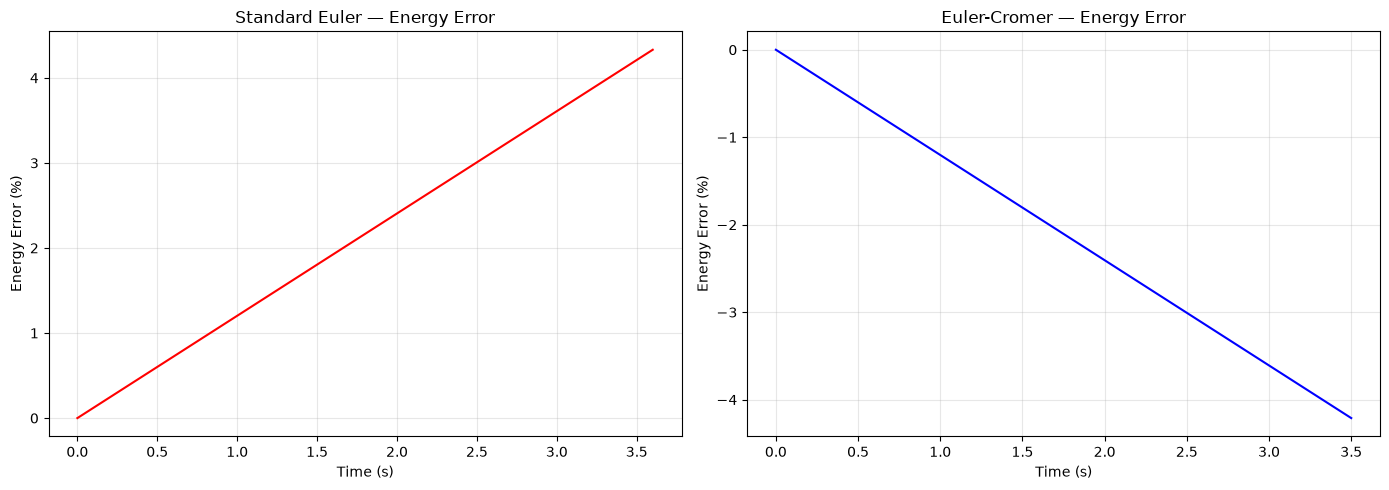

In [19]:
def simulate_projectile(method, dt, v0=20.0, angle_deg=60, g=9.81, m=1.0):
    """Simulate projectile with energy tracking.
    method: 'euler' or 'euler-cromer'
    """
    angle = np.radians(angle_deg)
    x, y = 0.0, 0.0
    vx, vy = v0 * np.cos(angle), v0 * np.sin(angle)

    ts, Es = [0.0], [0.5*m*(vx**2+vy**2) + m*g*y]
    t = 0.0

    while t < 10.0 and y >= 0:
        ax, ay = 0.0, -g

        if method == 'euler':
            x  += vx * dt        # position uses OLD velocity
            y  += vy * dt
            vx += ax * dt
            vy += ay * dt
        elif method == 'euler-cromer':
            vx += ax * dt        # velocity updated FIRST
            vy += ay * dt
            x  += vx * dt        # position uses NEW velocity
            y  += vy * dt

        t += dt
        E = 0.5 * m * (vx**2 + vy**2) + m * g * y
        ts.append(t); Es.append(E)

    return np.array(ts), np.array(Es)

# Compare at dt = 0.05 (deliberately coarse)
t_e, E_e   = simulate_projectile('euler',       dt=0.05)
t_ec, E_ec = simulate_projectile('euler-cromer', dt=0.05)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(t_e, (E_e - E_e[0])/abs(E_e[0])*100, 'r-')
ax1.set_title('Standard Euler — Energy Error')
ax1.set_xlabel('Time (s)'); ax1.set_ylabel('Energy Error (%)')
ax1.grid(True, alpha=0.3)

ax2.plot(t_ec, (E_ec - E_ec[0])/abs(E_ec[0])*100, 'b-')
ax2.set_title('Euler-Cromer — Energy Error')
ax2.set_xlabel('Time (s)'); ax2.set_ylabel('Energy Error (%)')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

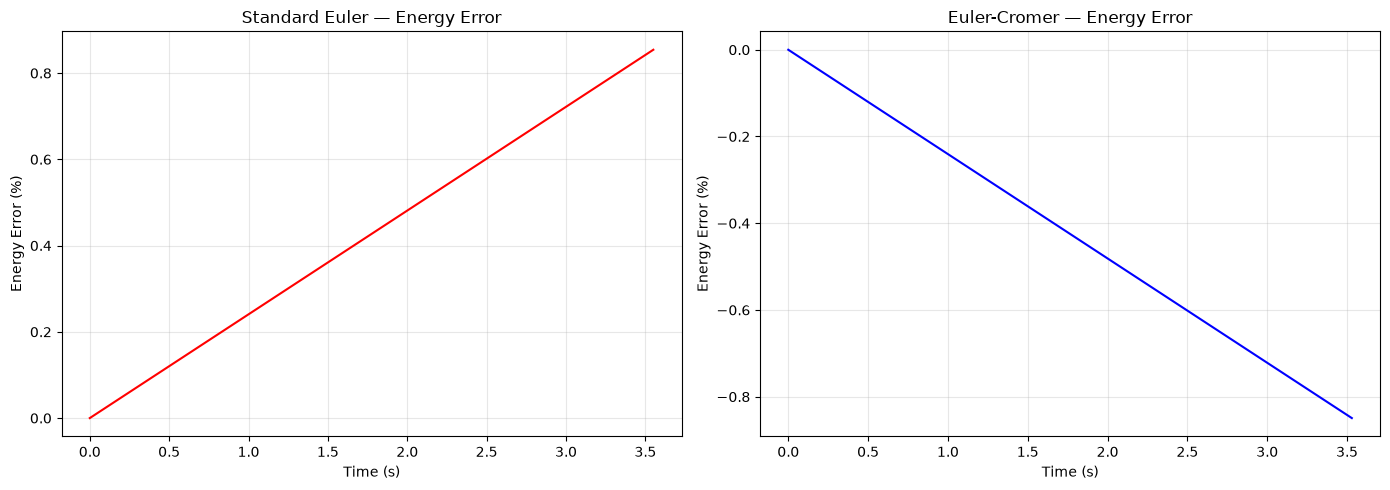

In [20]:
def simulate_projectile(method, dt, v0=20.0, angle_deg=60, g=9.81, m=1.0):
    """Simulate projectile with energy tracking.
    method: 'euler' or 'euler-cromer'
    """
    angle = np.radians(angle_deg)
    x, y = 0.0, 0.0
    vx, vy = v0 * np.cos(angle), v0 * np.sin(angle)

    ts, Es = [0.0], [0.5*m*(vx**2+vy**2) + m*g*y]
    t = 0.0

    while t < 10.0 and y >= 0:
        ax, ay = 0.0, -g

        if method == 'euler':
            x  += vx * dt        # position uses OLD velocity
            y  += vy * dt
            vx += ax * dt
            vy += ay * dt
        elif method == 'euler-cromer':
            vx += ax * dt        # velocity updated FIRST
            vy += ay * dt
            x  += vx * dt        # position uses NEW velocity
            y  += vy * dt

        t += dt
        E = 0.5 * m * (vx**2 + vy**2) + m * g * y
        ts.append(t); Es.append(E)

    return np.array(ts), np.array(Es)

# Compare at dt = 0.05 (deliberately coarse)
t_e, E_e   = simulate_projectile('euler',       dt=0.01)
t_ec, E_ec = simulate_projectile('euler-cromer', dt=0.01)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(t_e, (E_e - E_e[0])/abs(E_e[0])*100, 'r-')
ax1.set_title('Standard Euler — Energy Error')
ax1.set_xlabel('Time (s)'); ax1.set_ylabel('Energy Error (%)')
ax1.grid(True, alpha=0.3)

ax2.plot(t_ec, (E_ec - E_ec[0])/abs(E_ec[0])*100, 'b-')
ax2.set_title('Euler-Cromer — Energy Error')
ax2.set_xlabel('Time (s)'); ax2.set_ylabel('Energy Error (%)')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

🧪 Try it: Run the comparison above. Then change dt to 0.01 and run again. How does the energy error change for each method? Summarize: "For Euler, energy error ___. For Euler-Cromer, energy error ___." You'll use this observation in the discussion post this week.

For Euler, energy error the error goes futher up. For Euler-Cromer, energy error the error goes further down.

Carry this into Lab 2.  

When you write up your Euler vs. Euler-Cromer comparison, don't claim Euler-Cromer conserves energy better — your own data says otherwise. The correct conclusion is that the projectile cannot distinguish them, and you can say precisely why: the force doesn't depend on position, so the velocity is exact in both methods and the position errors are equal and opposite. That answer earns full credit. "Euler-Cromer is better" does not.

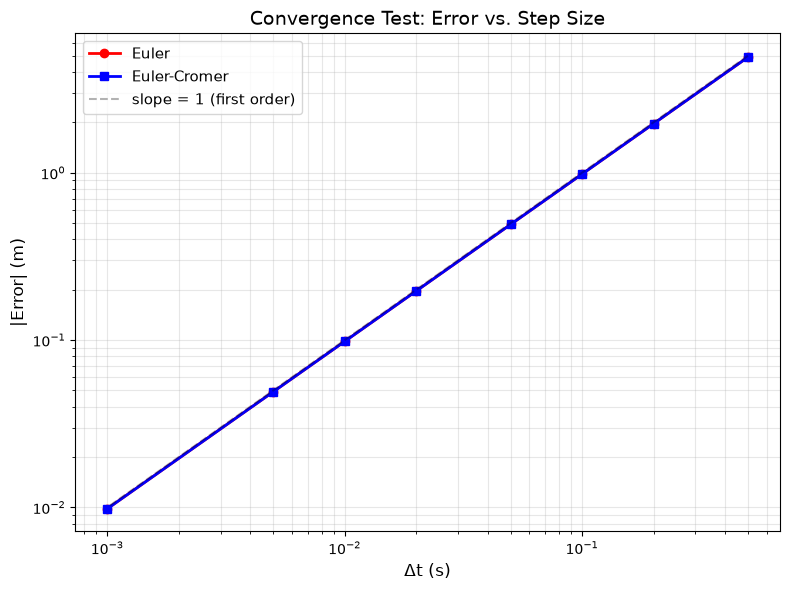

In [21]:
# Convergence test for projectile free fall
g = 9.81
t_final = 2.0
y0, vy0 = 100.0, 0.0  # dropped from 100 m
y_exact = y0 + vy0 * t_final - 0.5 * g * t_final**2

dt_values = [0.5, 0.2, 0.1, 0.05, 0.02, 0.01, 0.005, 0.001]
errors_euler = []
errors_ec = []

for dt in dt_values:
    # Standard Euler
    y, vy_curr = y0, vy0
    for _ in range(int(t_final / dt)):
        y  += vy_curr * dt
        vy_curr += -g * dt
    errors_euler.append(abs(y - y_exact))

    # Euler-Cromer
    y, vy_curr = y0, vy0
    for _ in range(int(t_final / dt)):
        vy_curr += -g * dt
        y  += vy_curr * dt
    errors_ec.append(abs(y - y_exact))

# Log-log plot
plt.figure(figsize=(8, 6))
plt.loglog(dt_values, errors_euler, 'ro-', label='Euler', linewidth=2)
plt.loglog(dt_values, errors_ec, 'bs-', label='Euler-Cromer', linewidth=2)
plt.loglog(dt_values, [d**1 * 10 for d in dt_values], 'k--', alpha=0.3, label='slope = 1 (first order)')
plt.xlabel('Δt (s)', fontsize=12)
plt.ylabel('|Error| (m)', fontsize=12)
plt.title('Convergence Test: Error vs. Step Size', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3, which='both')
plt.tight_layout()
plt.show()

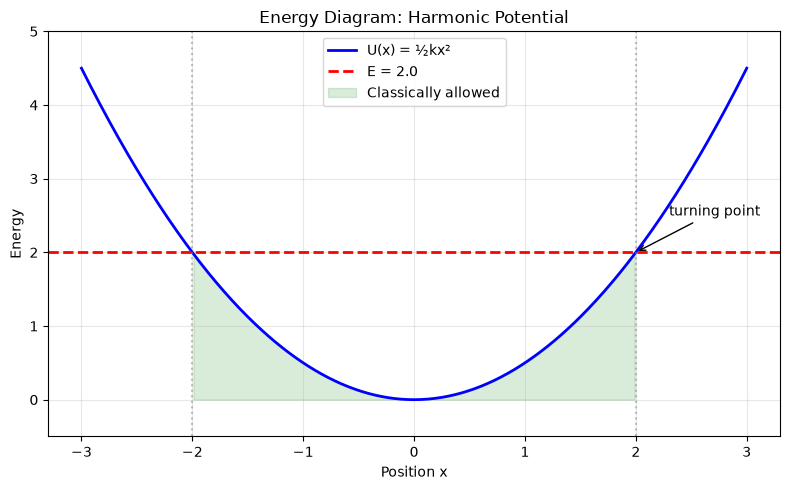

In [22]:
x = np.linspace(-3, 3, 500)
U = 0.5 * x**2  # harmonic potential well (spring)

E_total = 2.0   # total energy

plt.figure(figsize=(8, 5))
plt.plot(x, U, 'b-', linewidth=2, label='U(x) = ½kx²')
plt.axhline(y=E_total, color='r', linestyle='--', linewidth=2, label=f'E = {E_total}')

# Shade the classically allowed region
x_turn = np.sqrt(2 * E_total)  # turning points: U(x) = E
plt.fill_between(x, 0, U, where=(U <= E_total), alpha=0.15, color='green',
                 label='Classically allowed')
plt.axvline(x=-x_turn, color='gray', linestyle=':', alpha=0.5)
plt.axvline(x=x_turn,  color='gray', linestyle=':', alpha=0.5)
plt.annotate('turning point', xy=(x_turn, E_total), fontsize=10,
             xytext=(x_turn+0.3, E_total+0.5), arrowprops=dict(arrowstyle='->'))

plt.xlabel('Position x')
plt.ylabel('Energy')
plt.title('Energy Diagram: Harmonic Potential')
plt.legend()
plt.grid(True, alpha=0.3)
plt.ylim(-0.5, 5)
plt.tight_layout()
plt.show()